In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import torch

In [3]:
device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cpu"
)

print(device)

mps


In [4]:
data = pd.read_csv("../data/Cleaned_data2022-2025.csv")

In [5]:
data.head()

,Driver,Circuit,Year,LapNumber,LapsRemaining,Compound,TyreLife,TrackStatusSimple,Position,AirTemp,...,Pressure,TrackTemp,WindDirection,WindSpeed,Stint,Rainfall,InLap,OutLap,LapTimeSeconds,TargetLapTime
0,ALB,Austin,2022,1.0,55.0,MEDIUM,1.0,2,9.0,28.9,...,991.5,34.6,92,3.9,1.0,False,0,0,109.136,105.350
1,ALB,Austin,2022,2.0,54.0,MEDIUM,2.0,1,10.0,28.9,...,991.7,34.6,112,4.3,1.0,False,0,0,105.350,104.781
2,ALB,Austin,2022,3.0,53.0,MEDIUM,3.0,1,10.0,28.9,...,991.5,34.7,105,4.5,1.0,False,0,0,104.781,105.143
3,ALB,Austin,2022,4.0,52.0,MEDIUM,4.0,1,11.0,29.0,...,991.5,34.7,106,5.8,1.0,False,0,0,105.143,106.242
4,ALB,Austin,2022,5.0,51.0,MEDIUM,5.0,1,12.0,29.0,...,991.5,34.6,103,7.0,1.0,False,0,0,106.242,104.688


In [2]:
data.shape

NameError: name 'data' is not defined

### Preprocessing

In [6]:
cat_features = [
    'Driver',
    'Circuit',
    'Year',
    'Compound',
    'TrackStatusSimple',
    'Rainfall',
    'Stint',
    'Position',
]

num_features = [
    'LapNumber',
    'LapsRemaining',
    'TyreLife',
    'AirTemp',
    'Humidity',
    'Pressure',
    'TrackTemp',
    'WindDirection',
    'WindSpeed',
    'LapTimeSeconds',
]

binary_features = [
    'InLap',
    'OutLap'
]

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat",OneHotEncoder(handle_unknown="ignore"),cat_features),
        ("num",StandardScaler(),num_features),
        ("binary","passthrough",binary_features),
    ]
)

### Train test split

In [9]:
test_races = [
    "Shanghai",
    "Silverstone",
    "Spa-Francorchamps",
    "Spielberg",
    "Suzuka",
    "São Paulo",
    "Yas Island",
    "Zandvoort"
]

In [10]:
test_mask = (
    (data['Circuit'].isin(test_races)) &
    (data['Year'] == 2025)
)

In [11]:
train_data = data[~test_mask].copy()
test_data = data[test_mask].copy()

In [12]:
X_train = train_data.drop(columns=["TargetLapTime"])
y_train = train_data["TargetLapTime"]

X_test = test_data.drop(columns=["TargetLapTime"])
y_test = test_data["TargetLapTime"]

In [13]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [14]:
# One Hot Encoding turns it into a compressed Sparse Row sparse matrix, so use toarray()
X_train_processed = X_train_processed.toarray()
X_test_processed = X_test_processed.toarray()

### Tensorfying

In [15]:
X_train_processed.shape

(80602, 112)

In [16]:
X_train_tensor = torch.tensor(X_train_processed, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.to_numpy(), dtype=torch.float32).reshape(-1,1) # so ([8000])

X_test_tensor = torch.tensor(X_test_processed, dtype=torch.float32)

y_test_tensor = torch.tensor(y_test.to_numpy(), dtype=torch.float32).reshape(-1,1) # so ([8000])

### Dataset and Dataloader

In [17]:
from torch.utils.data import TensorDataset, DataLoader

In [18]:
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

In [19]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True, # will not shuffle for LSTMs and GRUs as they learn overtime (hidden state)
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=True
)

In [20]:
test_loader

### Model

In [21]:
import torch.nn as nn
import torch.optim as optim

In [22]:
input_size = X_train_tensor.shape[1]
input_size

112

In [23]:
class LapTimeNN(nn.Module):
    def __init__(self, input_size):
        super().__init__()

        self.layer1 = nn.Linear(input_size, 64)
        self.relu1 = nn.ReLU()
        self.layer2 = nn.Linear(64,32)
        self.relu2 = nn.ReLU()
        self.layer3 = nn.Linear(32,1)

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu1(x)
        x = self.layer2(x)
        x = self.relu2(x)
        x = self.layer3(x)

        return x


In [24]:
def init_model(input_size):
    torch.manual_seed(42)

    model = LapTimeNN(input_size)

    optimizer = optim.Adam(model.parameters(),lr=0.001)

    loss_function = nn.MSELoss()

    return model, optimizer, loss_function

In [29]:
def train_model(train_loader,input_size,epochs,verbose=True):
    losses = [] # init to store losses
    model, optimizer, loss_function = init_model(input_size)

    model = model.to(device)
    for epoch in range(epochs):

        model.train()
        total_loss = 0

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            #Forward prop
            output = model(X_batch)

            # Calc Loss
            loss = loss_function(output,y_batch)

            # Back prop
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * len(X_batch) # * len(X_batch) because last batch is smaller)

        avg_loss = total_loss / len(train_loader.dataset)

        losses.append(avg_loss)
            
        if verbose and (epoch + 1) % 10 == 0:
            print(
                f"Epoch [{epoch + 1}/{epochs}], "
                f"Loss: {avg_loss:.4f}"
            )

    return model, losses

In [30]:
model, losses = train_model(train_loader,input_size,100,verbose=True)

Epoch [10/100], Loss: 37.2668
Epoch [20/100], Loss: 33.3838
Epoch [30/100], Loss: 31.1783
Epoch [40/100], Loss: 28.6191
Epoch [50/100], Loss: 26.5928
Epoch [60/100], Loss: 25.0419
Epoch [70/100], Loss: 23.4197
Epoch [80/100], Loss: 22.0840
Epoch [90/100], Loss: 20.4692
Epoch [100/100], Loss: 19.0657


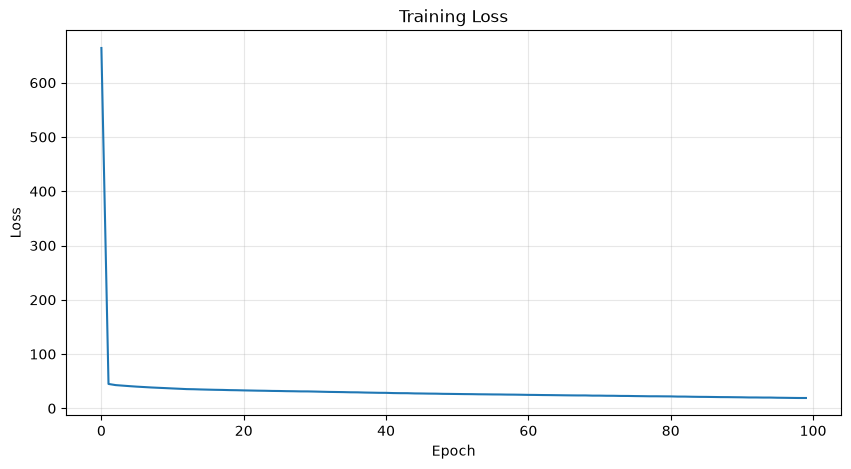

In [31]:
plt.figure(figsize=(10, 5))

plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.grid(True, alpha=0.3)
plt.show()

In [33]:
model.eval()

predictions = []

with torch.no_grad():
    for features, _ in test_loader:

        features = features.to(device)

        output = model(features)

        predictions.extend(
            output.cpu().numpy().flatten()
        )

predictions = np.array(predictions)

In [34]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

mae = mean_absolute_error(y_test, predictions)
rmse = root_mean_squared_error(y_test, predictions)

print(f"MAE:  {mae:.2f}s")
print(f"RMSE: {rmse:.2f}s")

MAE:  18.59s
RMSE: 25.04s


In [36]:
results = test_data.copy()

results["PredictionNN"] = predictions

results["ErrorNN"] = (
    results["PredictionNN"] - results["TargetLapTime"]
)

results["AbsoluteErrorNN"] = results["ErrorNN"].abs()

In [37]:
print(results["Circuit"].unique())
print(results["Year"].unique())

['Shanghai' 'Silverstone' 'Spa-Francorchamps' 'Spielberg' 'Suzuka'
 'São Paulo' 'Yas Island' 'Zandvoort']
[2025]


In [40]:
def plot_race(Year, Circuit, Driver):
    race = results[
        (results["Year"] == Year) &
        (results["Circuit"] == Circuit) & 
        (results["Driver"] == Driver)
    ]

    plt.figure(figsize=(12,6))
    
    plt.plot(
        race["LapNumber"],
        race["TargetLapTime"],
        label=f"{Driver} actual",
    )

    plt.plot(
        race["LapNumber"],
        race["PredictionNN"],
        label=f"{Driver} predicted",
        
    )

    plt.xlabel("Lap Number")
    plt.ylabel("Lap Time (s)")
    plt.title(f"{Driver} {Circuit} {Year} — Actual vs Predicted")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

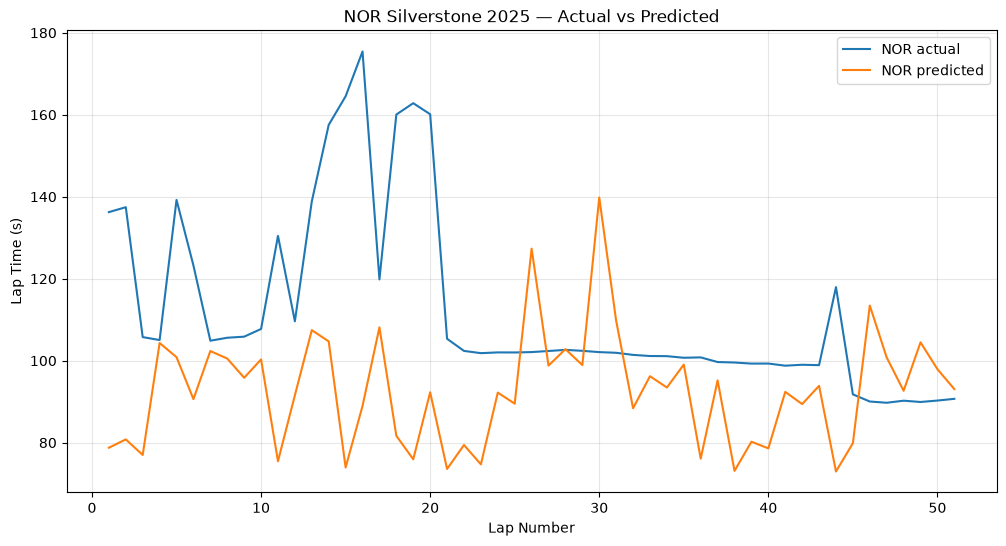

In [41]:
plot_race(2025,"Silverstone","NOR")